In [1]:
import pandas as pd
import requests
import zipfile
import os
from io import BytesIO
from sklearn.model_selection import train_test_split
import geopandas as gpd
from shapely.geometry import Point
import folium
import matplotlib.pyplot as plt
from folium.plugins import HeatMap

In [2]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print("Folders created.")

Folders created.


In [3]:
url = "https://divvy-tripdata.s3.amazonaws.com/202601-divvy-tripdata.zip"

response = requests.get(url)
print(response.status_code)

200


In [4]:
zip_file = zipfile.ZipFile(BytesIO(response.content))
zip_file.extractall("data/raw")

print("Downloaded and extracted.")

Downloaded and extracted.


In [5]:
os.listdir("data/raw")

['202501-divvy-tripdata.csv', '__MACOSX']

In [6]:
df = pd.read_csv("data/raw/202501-divvy-tripdata.csv")
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member


In [7]:
print("Rows, Columns:", df.shape)
print(df.columns.tolist())

Rows, Columns: (137787, 13)
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


In [8]:
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

df.dtypes

ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
dtype: object

In [9]:
df["trip_duration_minutes"]=(
    df["ended_at"]-df["started_at"]).dt.total_seconds() / 60

df[["started_at","ended_at","trip_duration_minutes"]].head()

,started_at,ended_at,trip_duration_minutes
0,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,15.021400
1,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,7.605467
2,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,6.739167
3,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,30.836433
4,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,78.447200


In [10]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary

end_station_name         27595
end_station_id           27595
start_station_name       24553
start_station_id         24553
end_lat                    196
end_lng                    196
ride_id                      0
rideable_type                0
started_at                   0
ended_at                     0
start_lat                    0
start_lng                    0
member_casual                0
trip_duration_minutes        0
dtype: int64

In [11]:
clean_df = df.dropna(subset=[
    "start_lat", "start_lng", "end_lat", "end_lng"
])

clean_df = clean_df[
    (clean_df["trip_duration_minutes"] > 1) &
    (clean_df["trip_duration_minutes"] <= 240)
]

clean_df.shape

(133396, 14)

In [12]:
clean_df["start_hour"] = clean_df["started_at"].dt.hour
clean_df["start_day"] = clean_df["started_at"].dt.day_name()
clean_df["start_date"] = clean_df["started_at"].dt.date
clean_df["is_weekend"] = clean_df["started_at"].dt.dayofweek >= 5

clean_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_minutes,start_hour,start_day,start_date,is_weekend
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member,15.021400,9,Saturday,2026-01-31,True
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual,7.605467,14,Thursday,2026-01-15,False
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member,6.739167,12,Tuesday,2026-01-06,False
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member,30.836433,16,Monday,2026-01-26,False
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member,78.447200,18,Saturday,2026-01-10,True


In [13]:
clean_df.to_csv("data/processed/divvy_cleaned.csv", index=False)

print("Cleaned data saved.")

Cleaned data saved.


In [14]:
clean_df = pd.read_csv("data/processed/divvy_cleaned.csv")

clean_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_minutes,start_hour,start_day,start_date,is_weekend
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member,15.021400,9,Saturday,2026-01-31,True
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual,7.605467,14,Thursday,2026-01-15,False
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member,6.739167,12,Tuesday,2026-01-06,False
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member,30.836433,16,Monday,2026-01-26,False
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member,78.447200,18,Saturday,2026-01-10,True


In [15]:
geometry = [
    Point(xy) for xy in zip(clean_df["start_lng"], clean_df["start_lat"])
]

trips_gdf = gpd.GeoDataFrame(
    clean_df,
    geometry=geometry,
    crs="EPSG:4326"
)

trips_gdf.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_minutes,start_hour,start_day,start_date,is_weekend,geometry
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member,15.021400,9,Saturday,2026-01-31,True,POINT (-87.68615 42.06431)
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual,7.605467,14,Thursday,2026-01-15,False,POINT (-87.58072 41.79521)
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member,6.739167,12,Tuesday,2026-01-06,False,POINT (-87.64242 41.93247)
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member,30.836433,16,Monday,2026-01-26,False,POINT (-87.65341 41.89453)
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member,78.447200,18,Saturday,2026-01-10,True,POINT (-87.64115 41.88166)


In [16]:
sample_trips = trips_gdf.sample(1000, random_state=42)

m = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

for _, row in sample_trips.iterrows():
    folium.CircleMarker(
        location=[row["start_lat"], row["start_lng"]],
        radius=2,
        popup=row["rideable_type"],
        fill=True
    ).add_to(m)

m

In [17]:
hourly_trips = (
    clean_df.groupby("start_hour")
    .size()
    .reset_index(name="trip_count")
)

hourly_trips

,start_hour,trip_count
0,0,1248
1,1,921
2,2,662
3,3,333
4,4,412
5,5,1767
6,6,4401
7,7,8039
8,8,10707
9,9,6323


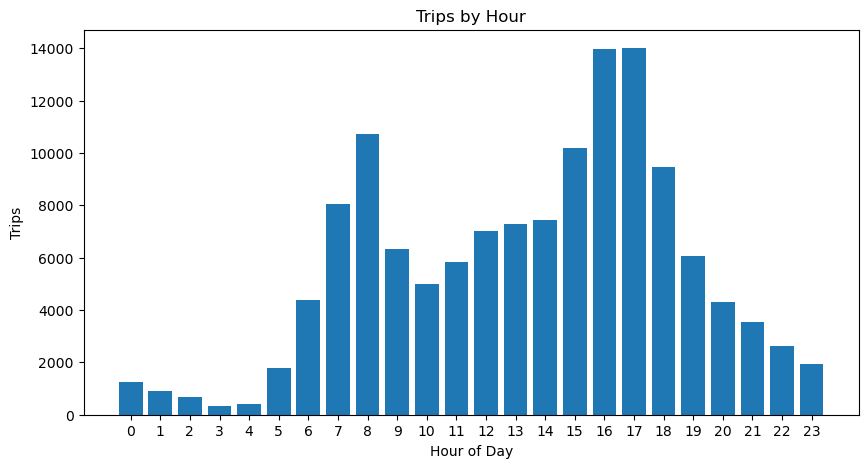

In [18]:
plt.figure(figsize=(10,5))
plt.bar(hourly_trips["start_hour"], hourly_trips["trip_count"])
plt.xlabel("Hour of Day")
plt.ylabel("Trips")
plt.title("Trips by Hour")
plt.xticks(range(0,24))
plt.show()

In [19]:
rider_type = (
    clean_df.groupby("member_casual")
    .size()
    .reset_index(name="trip_count")
)

rider_type

,member_casual,trip_count
0,casual,23807
1,member,109589


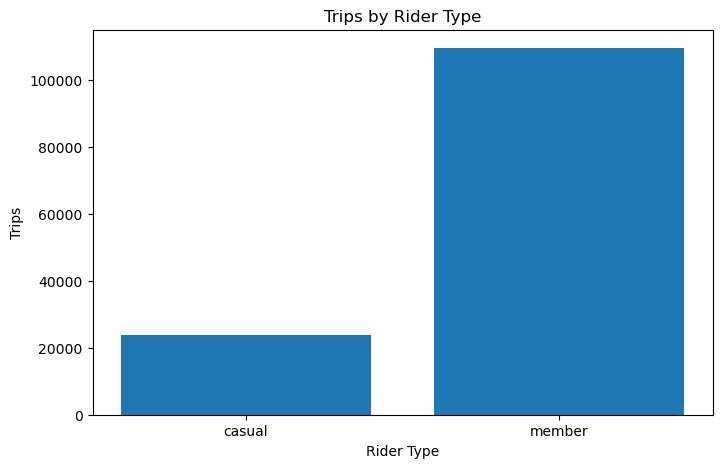

In [20]:
plt.figure(figsize=(8,5))
plt.bar(rider_type["member_casual"], rider_type["trip_count"])
plt.xlabel("Rider Type")
plt.ylabel("Trips")
plt.title("Trips by Rider Type")
plt.show()

In [21]:
week_usage = (
    clean_df.groupby("is_weekend")
    .size()
    .reset_index(name="trip_count")
)

week_usage["day_type"] = week_usage["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

week_usage

,is_weekend,trip_count,day_type
0,False,107826,Weekday
1,True,25570,Weekend


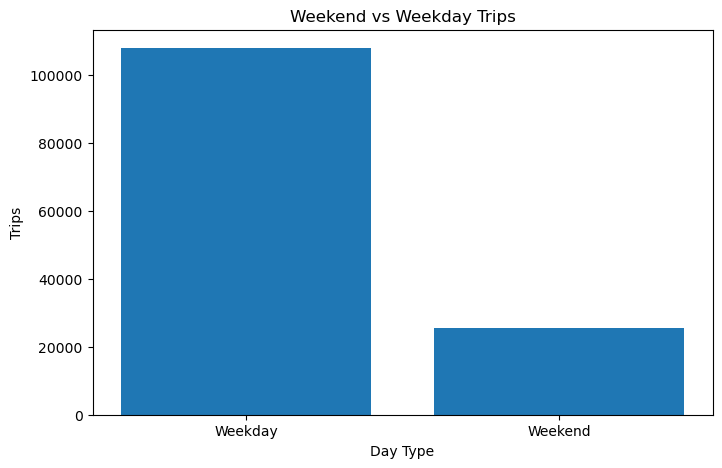

In [22]:
plt.figure(figsize=(8,5))
plt.bar(week_usage["day_type"], week_usage["trip_count"])
plt.xlabel("Day Type")
plt.ylabel("Trips")
plt.title("Weekend vs Weekday Trips")
plt.show()

In [23]:
avg_duration = (
    clean_df.groupby("member_casual")["trip_duration_minutes"]
    .mean()
    .reset_index()
)

avg_duration

,member_casual,trip_duration_minutes
0,casual,10.651577
1,member,10.054100


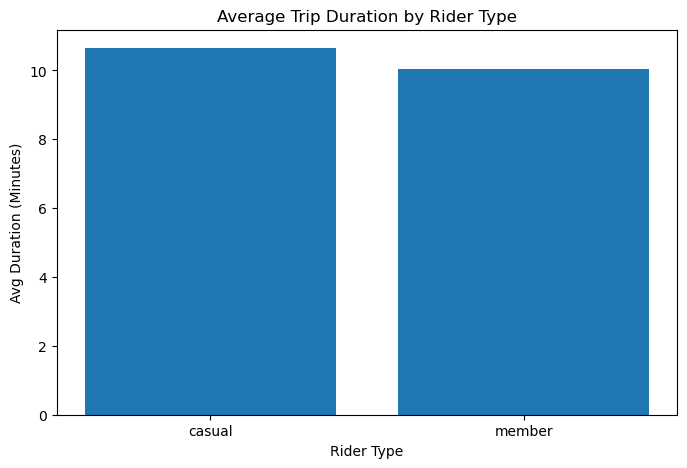

In [24]:
plt.figure(figsize=(8,5))
plt.bar(avg_duration["member_casual"], avg_duration["trip_duration_minutes"])
plt.xlabel("Rider Type")
plt.ylabel("Avg Duration (Minutes)")
plt.title("Average Trip Duration by Rider Type")
plt.show()

In [25]:
heat_data = clean_df[["start_lat", "start_lng"]].dropna().sample(5000, random_state=42).values.tolist()

heat_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

HeatMap(heat_data).add_to(heat_map)

heat_map

In [26]:
areas_url = "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"

areas_gdf = gpd.read_file(areas_url)

areas_gdf.head()

,community,shape_area,area_num_1,area_numbe,shape_len,geometry
0,ROGERS PARK,51259902.4506,1,1,34052.3975757,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,WEST RIDGE,98429094.8621,2,2,43020.6894583,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,UPTOWN,65095642.7289,3,3,46972.7945549,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,LINCOLN SQUARE,71352328.2399,4,4,36624.6030848,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,NORTH CENTER,57054167.85,5,5,31391.6697542,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


In [27]:
areas_gdf.columns

Index(['community', 'shape_area', 'area_num_1', 'area_numbe', 'shape_len',
       'geometry'],
      dtype='object')

In [28]:
areas_gdf = areas_gdf.to_crs(trips_gdf.crs)

In [29]:
trip_area_join = gpd.sjoin(
    trips_gdf,
    areas_gdf,
    how="left",
    predicate="within"
)

trip_area_join.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,start_day,start_date,is_weekend,geometry,index_right,community,shape_area,area_num_1,area_numbe,shape_len
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,...,Saturday,2026-01-31,True,POINT (-87.68615 42.06431),NaN,NaN,NaN,NaN,NaN,NaN
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,...,Thursday,2026-01-15,False,POINT (-87.58072 41.79521),40.0,HYDE PARK,45105380.1732,41,41,29746.7082016
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,...,Tuesday,2026-01-06,False,POINT (-87.64242 41.93247),6.0,LINCOLN PARK,88316400.4728,7,7,49478.4277714
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,...,Monday,2026-01-26,False,POINT (-87.65341 41.89453),23.0,WEST TOWN,127562904.597,24,24,55203.7186956
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,...,Saturday,2026-01-10,True,POINT (-87.64115 41.88166),27.0,NEAR WEST SIDE,158492466.554,28,28,53003.5929406


In [30]:
top_areas = (
    trip_area_join.groupby("community")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
    .head(10)
)

top_areas

,community,trip_count
46,NEAR NORTH SIDE,27676
48,NEAR WEST SIDE,20569
40,LOOP,15953
37,LINCOLN PARK,11496
36,LAKE VIEW,11063
74,WEST TOWN,10270
32,HYDE PARK,7084
39,LOGAN SQUARE,4545
65,UPTOWN,3457
47,NEAR SOUTH SIDE,2590


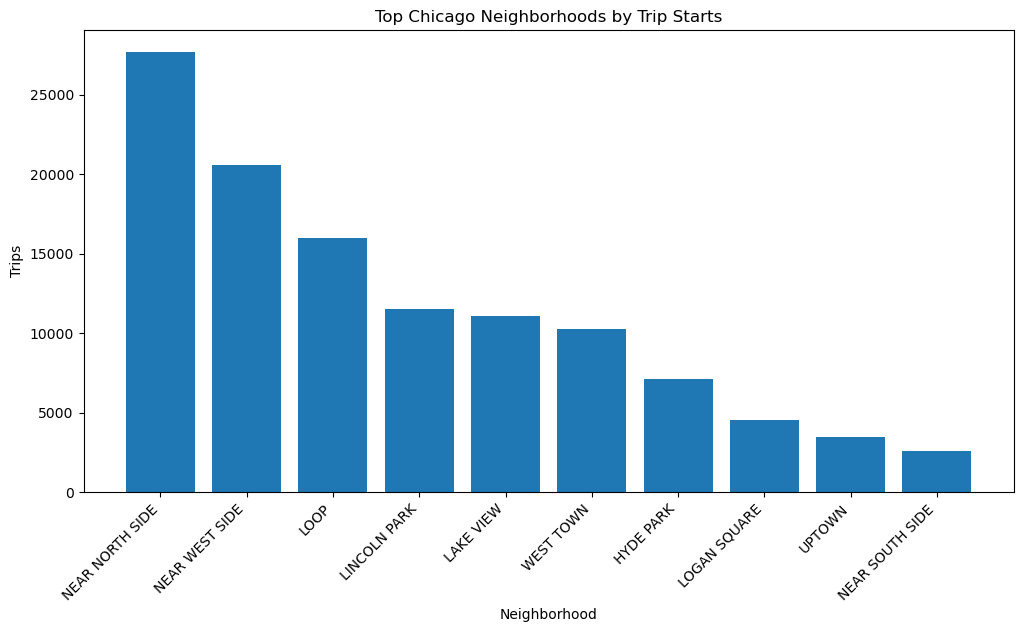

In [31]:
plt.figure(figsize=(12,6))
plt.bar(top_areas["community"], top_areas["trip_count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Neighborhood")
plt.ylabel("Trips")
plt.title("Top Chicago Neighborhoods by Trip Starts")
plt.show()

In [32]:
top_areas

,community,trip_count
46,NEAR NORTH SIDE,27676
48,NEAR WEST SIDE,20569
40,LOOP,15953
37,LINCOLN PARK,11496
36,LAKE VIEW,11063
74,WEST TOWN,10270
32,HYDE PARK,7084
39,LOGAN SQUARE,4545
65,UPTOWN,3457
47,NEAR SOUTH SIDE,2590


In [33]:
trip_area_join.to_csv("data/processed/divvy_with_community_areas.csv", index=False)

print("Spatial join data saved.")

Spatial join data saved.


In [34]:
hourly_df = (
    clean_df
    .groupby(["start_date", "start_hour"])
    .size()
    .reset_index(name="trip_count")
)

hourly_df.head()

,start_date,start_hour,trip_count
0,2025-12-31,23,17
1,2026-01-01,0,119
2,2026-01-01,1,186
3,2026-01-01,2,136
4,2026-01-01,3,32


In [35]:
hourly_df["start_date"] = pd.to_datetime(hourly_df["start_date"])

hourly_df["day_of_week"] = hourly_df["start_date"].dt.dayofweek
hourly_df["month"] = hourly_df["start_date"].dt.month
hourly_df["day"] = hourly_df["start_date"].dt.day

hourly_df.head()

,start_date,start_hour,trip_count,day_of_week,month,day
0,2025-12-31,23,17,2,12,31
1,2026-01-01,0,119,3,1,1
2,2026-01-01,1,186,3,1,1
3,2026-01-01,2,136,3,1,1
4,2026-01-01,3,32,3,1,1


In [36]:
X = hourly_df[["start_hour", "day_of_week", "month", "day"]]
y = hourly_df["trip_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [38]:
from sklearn.metrics import mean_absolute_error, r2_score

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", round(mae, 2))
print("R²:", round(r2, 3))

MAE: 36.55
R²: 0.863


In [39]:
future = pd.DataFrame({
    "start_hour": [8],
    "day_of_week": [4],   # Friday
    "month": [1],
    "day": [15]
})

prediction = model.predict(future)
print("Predicted Trips:", round(prediction[0]))

Predicted Trips: 296


In [40]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
0,start_hour,0.551732
3,day,0.300999
1,day_of_week,0.147266
2,month,0.000003


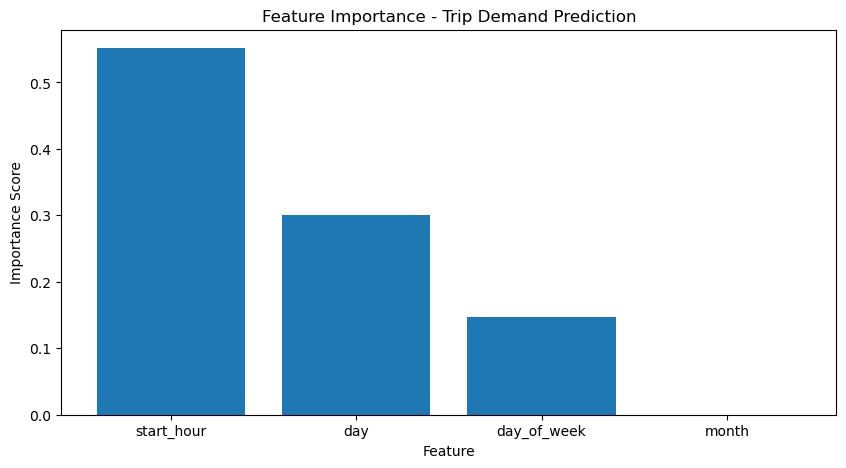

In [41]:
plt.figure(figsize=(10,5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.title("Feature Importance - Trip Demand Prediction")
plt.show()

In [42]:
results_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": preds
})

results_df.head()

,actual,predicted
0,63,90.375
1,23,37.115
2,70,47.115
3,247,239.115
4,125,86.085


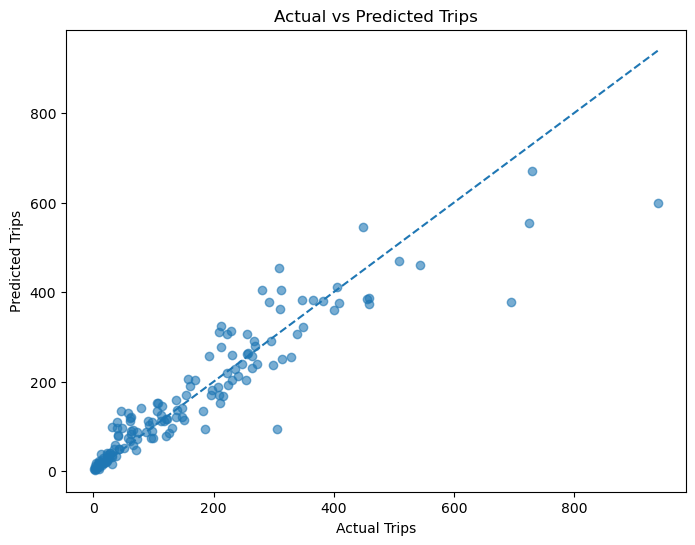

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(results_df["actual"], results_df["predicted"], alpha=0.6)
plt.xlabel("Actual Trips")
plt.ylabel("Predicted Trips")
plt.title("Actual vs Predicted Trips")

min_val = min(results_df["actual"].min(), results_df["predicted"].min())
max_val = max(results_df["actual"].max(), results_df["predicted"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

In [44]:
total_trips = len(clean_df)
avg_duration = clean_df["trip_duration_minutes"].mean()
unique_start_stations = clean_df["start_station_name"].nunique()
member_share = clean_df["member_casual"].value_counts(normalize=True) * 100

print("Total Trips:", total_trips)
print("Average Duration:", round(avg_duration, 2), "minutes")
print("Unique Start Stations:", unique_start_stations)
print(member_share)

Total Trips: 133396
Average Duration: 10.16 minutes
Unique Start Stations: 1133
member_casual
member    82.153138
casual    17.846862
Name: proportion, dtype: float64


<Axes: title={'center': 'Trips by Hour'}, xlabel='start_hour'>

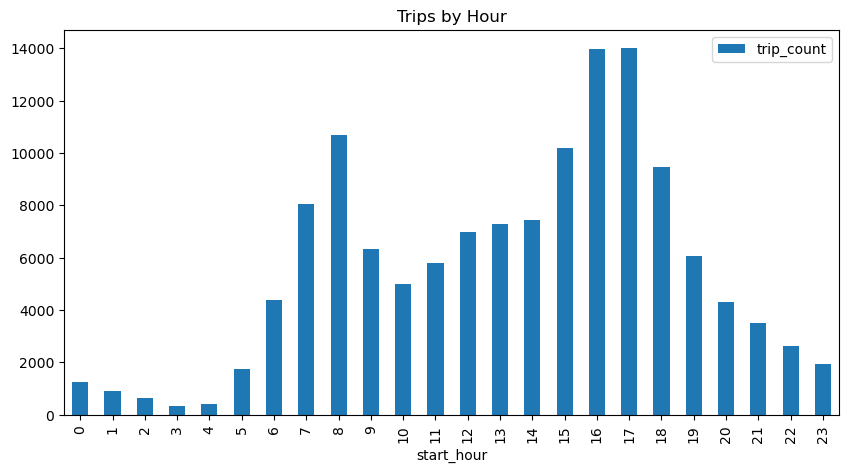

In [45]:
hourly_trips.plot(
    x="start_hour",
    y="trip_count",
    kind="bar",
    figsize=(10,5),
    title="Trips by Hour"
)

<Axes: title={'center': 'Trips by Rider Type'}, xlabel='member_casual'>

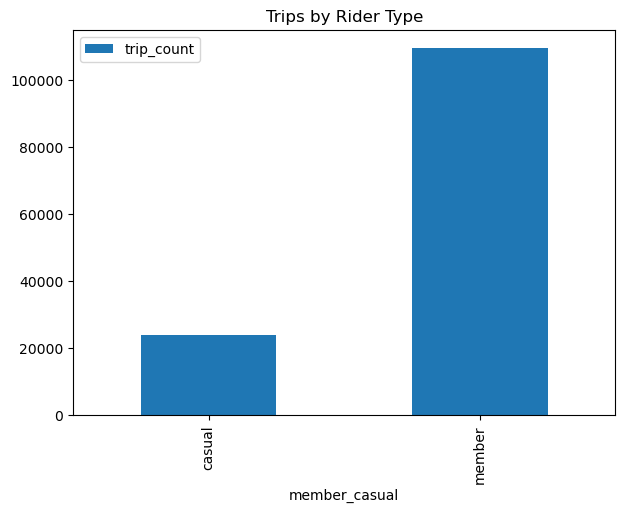

In [46]:
rider_type.plot(
    x="member_casual",
    y="trip_count",
    kind="bar",
    figsize=(7,5),
    title="Trips by Rider Type"
)

<Axes: title={'center': 'Top Chicago Neighborhoods by Trip Starts'}, xlabel='community'>

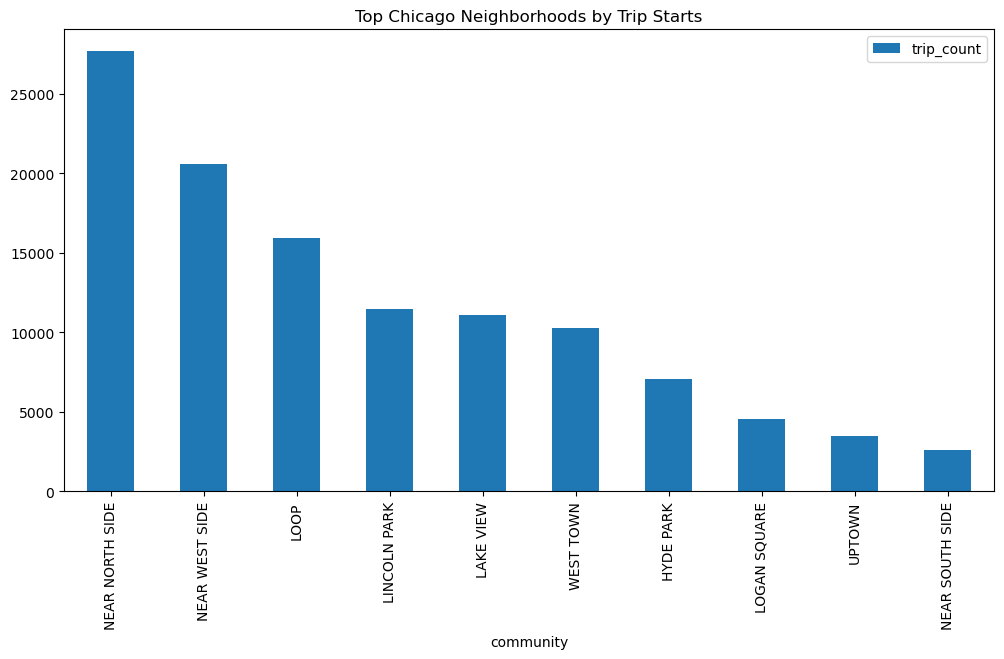

In [47]:
top_areas.plot(
    x="community",
    y="trip_count",
    kind="bar",
    figsize=(12,6),
    title="Top Chicago Neighborhoods by Trip Starts"
)

In [48]:
heat_map

<Axes: title={'center': 'Feature Importance - Demand Prediction'}, xlabel='feature'>

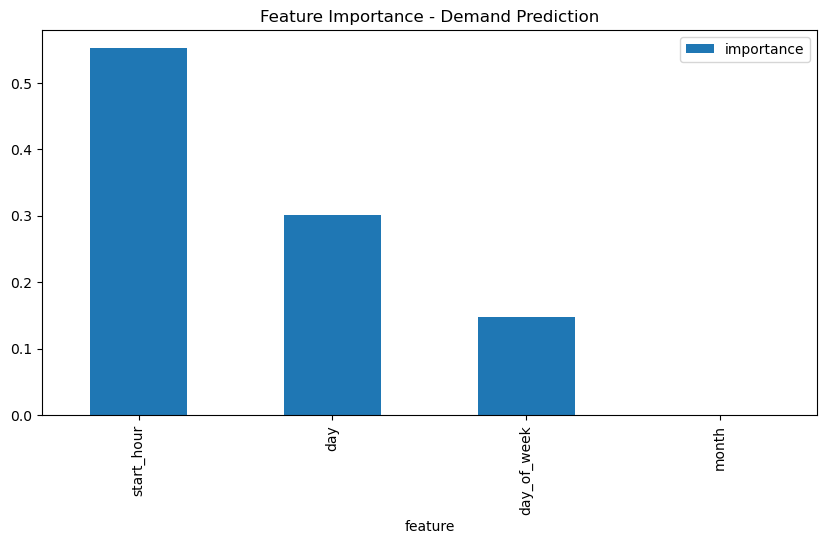

In [49]:
importance_df.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(10,5),
    title="Feature Importance - Demand Prediction"
)